# Tomato Leaf Disease Classification via Fine-Tuned ResNet

This notebook applies transfer learning to multi-class classification of tomato leaf diseases using the PlantVillage dataset. A pretrained ResNet backbone is fine-tuned under a staged freezing protocol and evaluated with group-aware cross-validation; macro-averaged F1 is reported to account for class imbalance.

## 1. Setup and Configuration

All paths, hyperparameters, and experimental settings are consolidated in the `CFG` class for reproducibility. Baseline configuration: ResNet-50, 5 epochs, batch size 128, AdamW (`lr=1e-3`, `weight_decay=1e-4`), and 7-fold cross-validation with seed 2026.

In [2]:
import os
import json
import datasets
import numpy as np
from kaggle_secrets import UserSecretsClient
import pyarrow.compute as pc
from sklearn.model_selection import StratifiedGroupKFold
import torch
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from torchvision.io import decode_image
from torchvision.transforms import v2
import pytorch_lightning as pl
from torchmetrics.classification import MulticlassF1Score
from pytorch_lightning.callbacks import Callback, ModelCheckpoint
from pytorch_lightning.loggers import CSVLogger
from datetime import datetime
import matplotlib.pyplot as plt

user_secrets = UserSecretsClient()
os.environ['HF_TOKEN'] = user_secrets.get_secret("HF_TOKEN")

In [3]:
class CFG:
    # --- Data Prep & Paths ---
    img_dir = "/kaggle/input/datasets/abdallahalidev/plantvillage-dataset/color"
    num_folds = 7
    seed = 2026
    splits_dir = f"splits_{num_folds}"
    save_dir = 'logs'
    model_dir = "models"
    

    # --- Training Hyperparameters ---
    variant = 50
    num_classes = None
    epochs = 5
    batch_size = 128
    num_workers = 4
    lr = 1e-3
    weight_decay = 1e-4
    warmup_ratio = 0.15
    unfreeze_ratio = 0.25 # backbone will be unfrozen at step unfreeze_ratio * total_step
    total_train_steps_logged = epochs * 4
    cv = num_folds # must be <= num_folds

## 2. Data Preparation and Cross-Validation Splits

The PlantVillage dataset is loaded via Hugging Face and filtered to the tomato subset; crop, disease condition, and leaf identity are parsed from image paths. As multiple images originate from the same leaf specimen, folds are built with `StratifiedGroupKFold` grouped by `leaf_id` to prevent intra-leaf leakage. Label mappings and splits are persisted as Parquet for reproducible, memory-efficient loading.

In [16]:
if not (os.path.isdir(CFG.splits_dir) and any(os.scandir(CFG.splits_dir))):
    os.makedirs(CFG.splits_dir, exist_ok=True)
    
    ds = datasets.load_dataset("mohanty/PlantVillage", 'default')
    ds = datasets.concatenate_datasets([ds['train'], ds['test']])
    ds = ds.filter(lambda r: '/color/' in r['text'])

    # Extract leaf ID, crop type, disease condition, and relative image path from the metadata string
    def parse_metadata(batch):
        return {
            'leaf_id': [x.split('/')[-1].split('___')[0] for x in batch['text']],
            'crop': [x.split('/')[-2].split('___')[0] for x in batch['text']],
            'condition': [x.split('/')[-2].split('___')[1] for x in batch['text']],
            'image': [x.replace('raw/color/', '') for x in batch['text']],
        }
    
    ds = ds.map(parse_metadata, batched=True, batch_size=1000, num_proc=CFG.num_workers, remove_columns='text')
    
    display(datasets.Dataset(
        ds.data.table.group_by('crop')
        .aggregate([
            ('leaf_id', 'count'),
            ('leaf_id', 'count_distinct'),
            ('condition', 'count_distinct'),
        ])
    ).to_pandas())
    
    display(datasets.Dataset(
        ds.data.table
        .filter(pc.field('crop') == 'Tomato')
        .group_by(['condition'])
        .aggregate([
            ('leaf_id', 'count'),
            ('leaf_id', 'count_distinct'),
        ])
    ).to_pandas())
    
    tomato = ds.filter(lambda row: row['crop'] == 'Tomato')
    print('Tomato / Total : ', len(tomato), '/', len(ds))

    # Generate and save mapping dictionaries to convert string conditions into integer class indices
    label2idx = {label:idx for idx, label in enumerate(np.unique(tomato['condition']))}
    idx2label = {idx:label for label, idx in label2idx.items()}
    
    with open(os.path.join(CFG.splits_dir, 'label2idx.json'), 'w') as file:
        json.dump(label2idx, file, indent=4)
        
    with open(os.path.join(CFG.splits_dir, 'idx2label.json'), 'w') as file:
        json.dump(idx2label, file, indent=4)

    # Use StratifiedGroupKFold to prevent data leakage by ensuring identical leaves stay in the same split
    sgkf = StratifiedGroupKFold(n_splits=CFG.num_folds, shuffle=True, random_state=CFG.seed)
    X = np.arange(len(tomato))
    y = np.array(tomato['condition'])
    groups = np.array(tomato['leaf_id'])
    
    fold_indices = [test_idx for _, test_idx in sgkf.split(X, y, groups)]
    tomato = tomato.remove_columns(['leaf_id', 'crop'])
    
    cv_dict = {}
    for i in range(CFG.num_folds):
        cv_dict[f'train_{i}'] = tomato.select(np.concatenate(fold_indices[(i+1)//CFG.num_folds:i] + fold_indices[i+2:]))
        cv_dict[f'val_{i}'] = tomato.select(fold_indices[i])
        cv_dict[f'test_{i}'] = tomato.select(fold_indices[(i +1) % CFG.num_folds])
    
    tomato_cv = datasets.DatasetDict(cv_dict)
    
    datasets.disable_progress_bar()
    
    os.makedirs(CFG.splits_dir, exist_ok=True)
    # Save the dataset splits as Parquet files for fast, memory-efficient loading during training
    for name, split in tomato_cv.items():
        split.to_parquet(os.path.join(CFG.splits_dir, f'tomato_{name}.parquet'))
    
    datasets.enable_progress_bar()

,crop,leaf_id_count,leaf_id_count_distinct,condition_count_distinct
0,Raspberry,371,371,1
1,Potato,2152,2152,3
2,Corn_(maize),3852,3852,4
3,Cherry_(including_sour),1906,1906,2
4,Orange,5507,5507,1
5,Soybean,5090,5090,1
6,Strawberry,1565,1565,2
7,Grape,4062,4062,4
8,"Pepper,_bell",2475,2475,2
9,Tomato,18160,18160,10


,condition,leaf_id_count,leaf_id_count_distinct
0,Early_blight,1000,1000
1,Target_Spot,1404,1404
2,Bacterial_spot,2127,2127
3,Septoria_leaf_spot,1771,1771
4,Tomato_Yellow_Leaf_Curl_Virus,5357,5357
5,Spider_mites Two-spotted_spider_mite,1676,1676
6,Late_blight,1909,1909
7,healthy,1591,1591
8,Leaf_Mold,952,952
9,Tomato_mosaic_virus,373,373


Tomato / Total :  18160 / 54305


## 3. Dataset and Data Loading

A PyTorch `Dataset` reads Parquet annotations, decodes images on the fly, and applies label mapping with the split-specific transform pipeline. DataLoaders use pinned memory, with shuffling enabled for training only.

In [17]:
class TomatoLeafDiseaseDataset(Dataset):
    def __init__(self, annotation_file, img_dir, transform=None, target_transform=None):
        self.img_label = pd.read_parquet(annotation_file)
        self.img_dir = img_dir
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.img_label)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_label.iloc[idx, 1])
        image = decode_image(img_path)
        label = self.img_label.iloc[idx, 0]
        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)
        return image, label

## 4. Data Augmentation

Training samples undergo colour jitter, horizontal/vertical flips, and rotations within ±15° to encourage invariance to pose and illumination and to reduce overfitting. Validation and test samples receive only dtype scaling and ImageNet normalisation, ensuring deterministic evaluation.

In [18]:
with open(os.path.join(CFG.splits_dir, 'label2idx.json'), "r") as file:
    label2idx = json.load(file)
    
with open(os.path.join(CFG.splits_dir, 'idx2label.json'), "r") as file:
    idx2label = json.load(file)

target_transform = lambda x: label2idx[x]

# Define data augmentations for training to prevent overfitting and improve generalization
_augment = [
    v2.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1, hue=0.0),
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomVerticalFlip(p=0.5),
    v2.RandomRotation(degrees=(-15, 15), expand=False),
    # v2.Resize((256, 256)), # use this when expand=True above
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
]

augment = v2.Compose(_augment)
# Isolate scaling and normalization into a separate pipeline for validation and testing
preproc = v2.Compose(_augment[-2:])
CFG.num_classes = len(label2idx)

## 5. Model Architecture

A pretrained ResNet-50 (ImageNet weights, via `torch.hub`) serves as the backbone. All backbone parameters are initially frozen and the final fully-connected layer is replaced with a linear head sized to the number of disease classes, restricting early training to the new head alone.

In [19]:
# Load a pretrained ResNet, freeze the backbone weights, and swap the final classification head
def get_model(variant, num_classes):
    weights = torch.hub.load('pytorch/vision', 'get_weight', name = f'ResNet{variant}_Weights.DEFAULT')
    model = torch.hub.load('pytorch/vision', f'resnet{variant}', weights = weights)
    
    for param in model.parameters():
        param.requires_grad = False
    
    in_features = model.fc.in_features
    model.fc = torch.nn.Linear(in_features, num_classes)
    
    return model

## 6. Training Objective and Optimisation

The Lightning module combines cross-entropy loss with per-class and macro-averaged F1 tracking. AdamW is scheduled with linear warm-up over 15% of total steps followed by cosine annealing, stepped per iteration. Validation macro-F1 drives checkpoint selection, prioritising minority-class performance.

In [20]:
# PyTorch Lightning module encapsulating the forward pass, loss calculation, and logging logic
class TomatoClassifier(pl.LightningModule):
    def __init__(self, model, num_classes, idx2label, lr, weight_decay, total_steps, warmup_ratio):
        super().__init__()
        self.model = model
        self.lr = lr
        self.weight_decay = weight_decay
        self.criterion = torch.nn.CrossEntropyLoss()
        
        self.total_steps = total_steps
        self.warmup_steps = int(warmup_ratio * total_steps)

        self.idx2label = idx2label
        self.f1 = MulticlassF1Score(num_classes=num_classes, average=None)
        self.f1_macro = MulticlassF1Score(num_classes=num_classes, average="macro")

    def forward(self, x):
        return self.model(x)

    def predict_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        probs = torch.softmax(logits, dim=1)
        return probs, y

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = self.criterion(y_pred, y)

        self.log('train_loss', loss, on_step=True, on_epoch=True, prog_bar=True, logger=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = self.criterion(y_pred, y)

        self.f1(y_pred, y)
        self.f1_macro(y_pred, y)

        self.log('val_loss', loss, on_step=False, on_epoch=True, prog_bar=True, logger=True)
        self.log('f1_macro', self.f1_macro, on_step=False, on_epoch=True, prog_bar=True, logger=True)

        return loss

    def on_validation_epoch_end(self):
        f1 = self.f1.compute()
        for idx, label in self.idx2label.items():
            self.log(f"f1_{label}", f1[int(idx)], prog_bar=False, logger=True)
        self.f1.reset()

    # Configure a learning rate schedule with a linear warmup phase followed by cosine annealing decay
    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=self.lr, weight_decay=self.weight_decay)

        linear = torch.optim.lr_scheduler.LinearLR(
            optimizer, start_factor=0.01, end_factor=1.0, total_iters=self.warmup_steps)
        cosine = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max = self.total_steps - self.warmup_steps)

        scheduler = torch.optim.lr_scheduler.SequentialLR(
            optimizer, schedulers=[linear, cosine], milestones=[self.warmup_steps])

        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "interval": "step",
                "frequency": 1
            }
        }

## 7. Staged Fine-Tuning

Full fine-tuning is deferred: the backbone stays frozen for the first 25% of training steps so the new classification head converges first, after which an `UnfreezeBackbone` callback releases all parameters. This staged schedule stabilises early optimisation and limits catastrophic forgetting of pretrained features.

In [21]:
# Custom callback to unfreeze the ResNet backbone weights at a specific global training step
class UnfreezeBackbone(Callback):
    def __init__(self, unfreeze_step):
        self.unfreeze_step = unfreeze_step

    def on_train_batch_start(self, trainer, pl_module, batch, batch_idx):
        if trainer.global_step == self.unfreeze_step:
            for param in pl_module.model.parameters():
                param.requires_grad = True
            # uncommet pl_module.print only if exexuting this code as script
            # pl_module.print(f"\n--- Unfrozen Backbone at Epoch {self.unfreeze_epoch} ---")

## 8. Cross-Validation Training Loop

Each fold re-initialises the model and Lightning module to prevent weight carry-over, trains for 5 epochs, and retains the checkpoint with the highest validation macro-F1. Test predictions are accumulated out-of-fold, yielding per-class and macro F1 with mean ± standard deviation across folds.

In [22]:
exp_name = f'resnet{CFG.variant}_baseline'
exp_version_id = datetime.now().strftime("%y%m%d%H%M")

CFG.exp_name = exp_name

# Initialize standalone metric objects to accumulate global Out-Of-Fold (OOF) scores across all splits
f1 = MulticlassF1Score(num_classes=CFG.num_classes, average=None)
f1_macro = MulticlassF1Score(num_classes=CFG.num_classes, average='macro')

fold_test_f1_macro = []

for fold in range(CFG.cv):
    print(f"\n===================================")
    print(f"         TRAINING FOLD {fold}         ")
    print(f"===================================\n")
    
    exp_version = f'{exp_version_id}_{fold}'
    CFG.exp_version = exp_version
    
    train_file_path = f'{CFG.splits_dir}/tomato_train_{fold}.parquet'
    val_file_path = f'{CFG.splits_dir}/tomato_val_{fold}.parquet'
    test_file_path = f'{CFG.splits_dir}/tomato_test_{fold}.parquet'
    
    
    training_dataset = TomatoLeafDiseaseDataset(train_file_path, CFG.img_dir, augment, target_transform)
    validation_dataset = TomatoLeafDiseaseDataset(val_file_path, CFG.img_dir, preproc, target_transform)
    test_dataset = TomatoLeafDiseaseDataset(test_file_path, CFG.img_dir, preproc, target_transform)
    
    train_dataloader = DataLoader(training_dataset, batch_size=CFG.batch_size, num_workers=CFG.num_workers, pin_memory=True, shuffle=True, drop_last=True)
    val_dataloader = DataLoader(validation_dataset, batch_size=CFG.batch_size, num_workers=CFG.num_workers, pin_memory=True, shuffle=False)
    test_dataloader = DataLoader(test_dataset, batch_size=CFG.batch_size, num_workers=CFG.num_workers, pin_memory=True, shuffle=False)

    # Reinitialize the model, LightningModule, and DataLoaders per fold to prevent weight leakage
    model = get_model(CFG.variant, CFG.num_classes)
    total_steps = int(CFG.epochs * len(train_dataloader))
    CFG.total_steps = total_steps
    pl_module = TomatoClassifier(
        model,
        CFG.num_classes, 
        idx2label, 
        CFG.lr, 
        CFG.weight_decay, 
        CFG.total_steps, 
        CFG.warmup_ratio
    )
    
    unfreeze_step = int(CFG.total_steps * CFG.unfreeze_ratio + 1)
    checkpoint_callback = ModelCheckpoint(
        dirpath=CFG.model_dir,
        filename=f"best_{exp_name}_{exp_version}",
        monitor="f1_macro",
        mode="max",
        save_top_k=1
    )

    # Save the entire CFG dictionary to the logger so hyperparameters are tracked in the metrics.csv
    cfg_dict = {k: v for k, v in CFG.__dict__.items() if not k.startswith("__")}
    
    logger = CSVLogger(save_dir=CFG.save_dir, name=exp_name, version=exp_version)
    logger.log_hyperparams(cfg_dict)

    log_freq = int(total_steps//CFG.total_train_steps_logged)
    trainer = pl.Trainer(
        max_epochs=CFG.epochs,
        val_check_interval=log_freq,
        log_every_n_steps=log_freq,
        callbacks=[UnfreezeBackbone(unfreeze_step), checkpoint_callback],
        logger=logger,
        accelerator="gpu",
        devices=1
    )
    
    trainer.fit(model=pl_module, train_dataloaders=train_dataloader, val_dataloaders=val_dataloader)

    test_preds = trainer.predict(pl_module, test_dataloader, ckpt_path='best')

    test_probs = torch.cat([batch[0] for batch in test_preds])
    test_targets = torch.cat([batch[1] for batch in test_preds])

    test_preds = {'test_probs': test_probs, 'test_targets': test_targets} 
    torch.save(test_preds, f'{CFG.model_dir}/{exp_name}_{exp_version}.pt')

    _f1 = f1(test_probs, test_targets)
    _f1_macro = f1_macro(test_probs, test_targets).item()

    fold_test_f1_macro.append(_f1_macro)
    logger.log_metrics({"test_f1_macro": _f1_macro})
    print("Fold", fold, " Test F1 Macro: ", _f1_macro)
    
    for idx, label in idx2label.items():
        logger.log_metrics({f"f1_{label}": _f1[int(idx)].item()})
        print(f"F1_{label}", _f1[int(idx)].item())
    logger.save()

    # to get all class f1 score and test_f1_macro in a single row at last change above code to this
    # log_metrics = {"test_f1_macro": _f1_macro}
    # print("Fold", fold, " Test F1 Macro: ", _f1_macro)
    
    # for idx, label in idx2label.items():
    #     log_metrics[f"f1_{label}"] =  _f1[int(idx)].item()
    #     print(f"F1_{label}", _f1[int(idx)].item())
    # logger.log_metrics(log_metrics)
    # logger.save()
    
    

print("=="*80)
print("=="*80)
print("Test F1 Macro: ", np.mean(fold_test_f1_macro).item(), " +/- ", np.std(fold_test_f1_macro).item())
print("OOF Test F1 Macro: ", f1_macro.compute())
oof_f1 = f1.compute()
for idx, label in idx2label.items():
    print(f"OOF F1_{label}", oof_f1[int(idx)].item()) 


         TRAINING FOLD 0         



Using cache found in /root/.cache/torch/hub/pytorch_vision_main
Using cache found in /root/.cache/torch/hub/pytorch_vision_main
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ ResNet            │ 23.5 M │ train │     0 │
│ 1 │ criterion │ CrossEntropyLoss  │      0 │ train │     0 │
│ 2 │ f1        │ MulticlassF1Score │      0 │ train │     0 │
│ 3 │ f1_macro  │ MulticlassF1Score │      0 │ train │     0 │
└───┴───────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 20.5 K                                                                                           
Non-trainable params: 23.5 M                                                                                       
Total params: 23.5 M                                                                                               
Total estimated model params size (MB): 94.114                                                                     
Modules in train mode: 154                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

...

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

`Trainer.fit` stopped: `max_epochs=5` reached.


Restoring states from the checkpoint path at /kaggle/working/models/best_resnet50_baseline_2610070100_6.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
Loaded model weights from the checkpoint at /kaggle/working/models/best_resnet50_baseline_2610070100_6.ckpt


Output()

Fold 6  Test F1 Macro:  0.9946988821029663
F1_Bacterial_spot 0.9952903985977173
F1_Early_blight 0.9923076629638672
F1_Late_blight 0.9946140050888062
F1_Leaf_Mold 1.0
F1_Septoria_leaf_spot 0.99622642993927
F1_Spider_mites Two-spotted_spider_mite 0.9918367266654968
F1_Target_Spot 0.9878934621810913
F1_Tomato_Yellow_Leaf_Curl_Virus 0.9987212419509888
F1_Tomato_mosaic_virus 0.9900990128517151
F1_healthy 1.0
Test F1 Macro:  0.9954453706741333  +/-  0.0011785129764502124
OOF Test F1 Macro:  tensor(0.9955)
OOF F1_Bacterial_spot 0.9957607388496399
OOF F1_Early_blight 0.987939715385437
OOF F1_Late_blight 0.9934503436088562
OOF F1_Leaf_Mold 0.9984235167503357
OOF F1_Septoria_leaf_spot 0.9974640607833862
OOF F1_Spider_mites Two-spotted_spider_mite 0.9949420094490051
OOF F1_Target_Spot 0.9910873174667358
OOF F1_Tomato_Yellow_Leaf_Curl_Virus 0.9984146356582642
OOF F1_Tomato_mosaic_virus 0.9986577033996582
OOF F1_healthy 0.9984281659126282


## 9. Training Curves and Diagnostics

CSV logs from each fold are parsed to plot training and validation loss alongside macro-F1, providing a per-split view of convergence and overfitting behaviour.

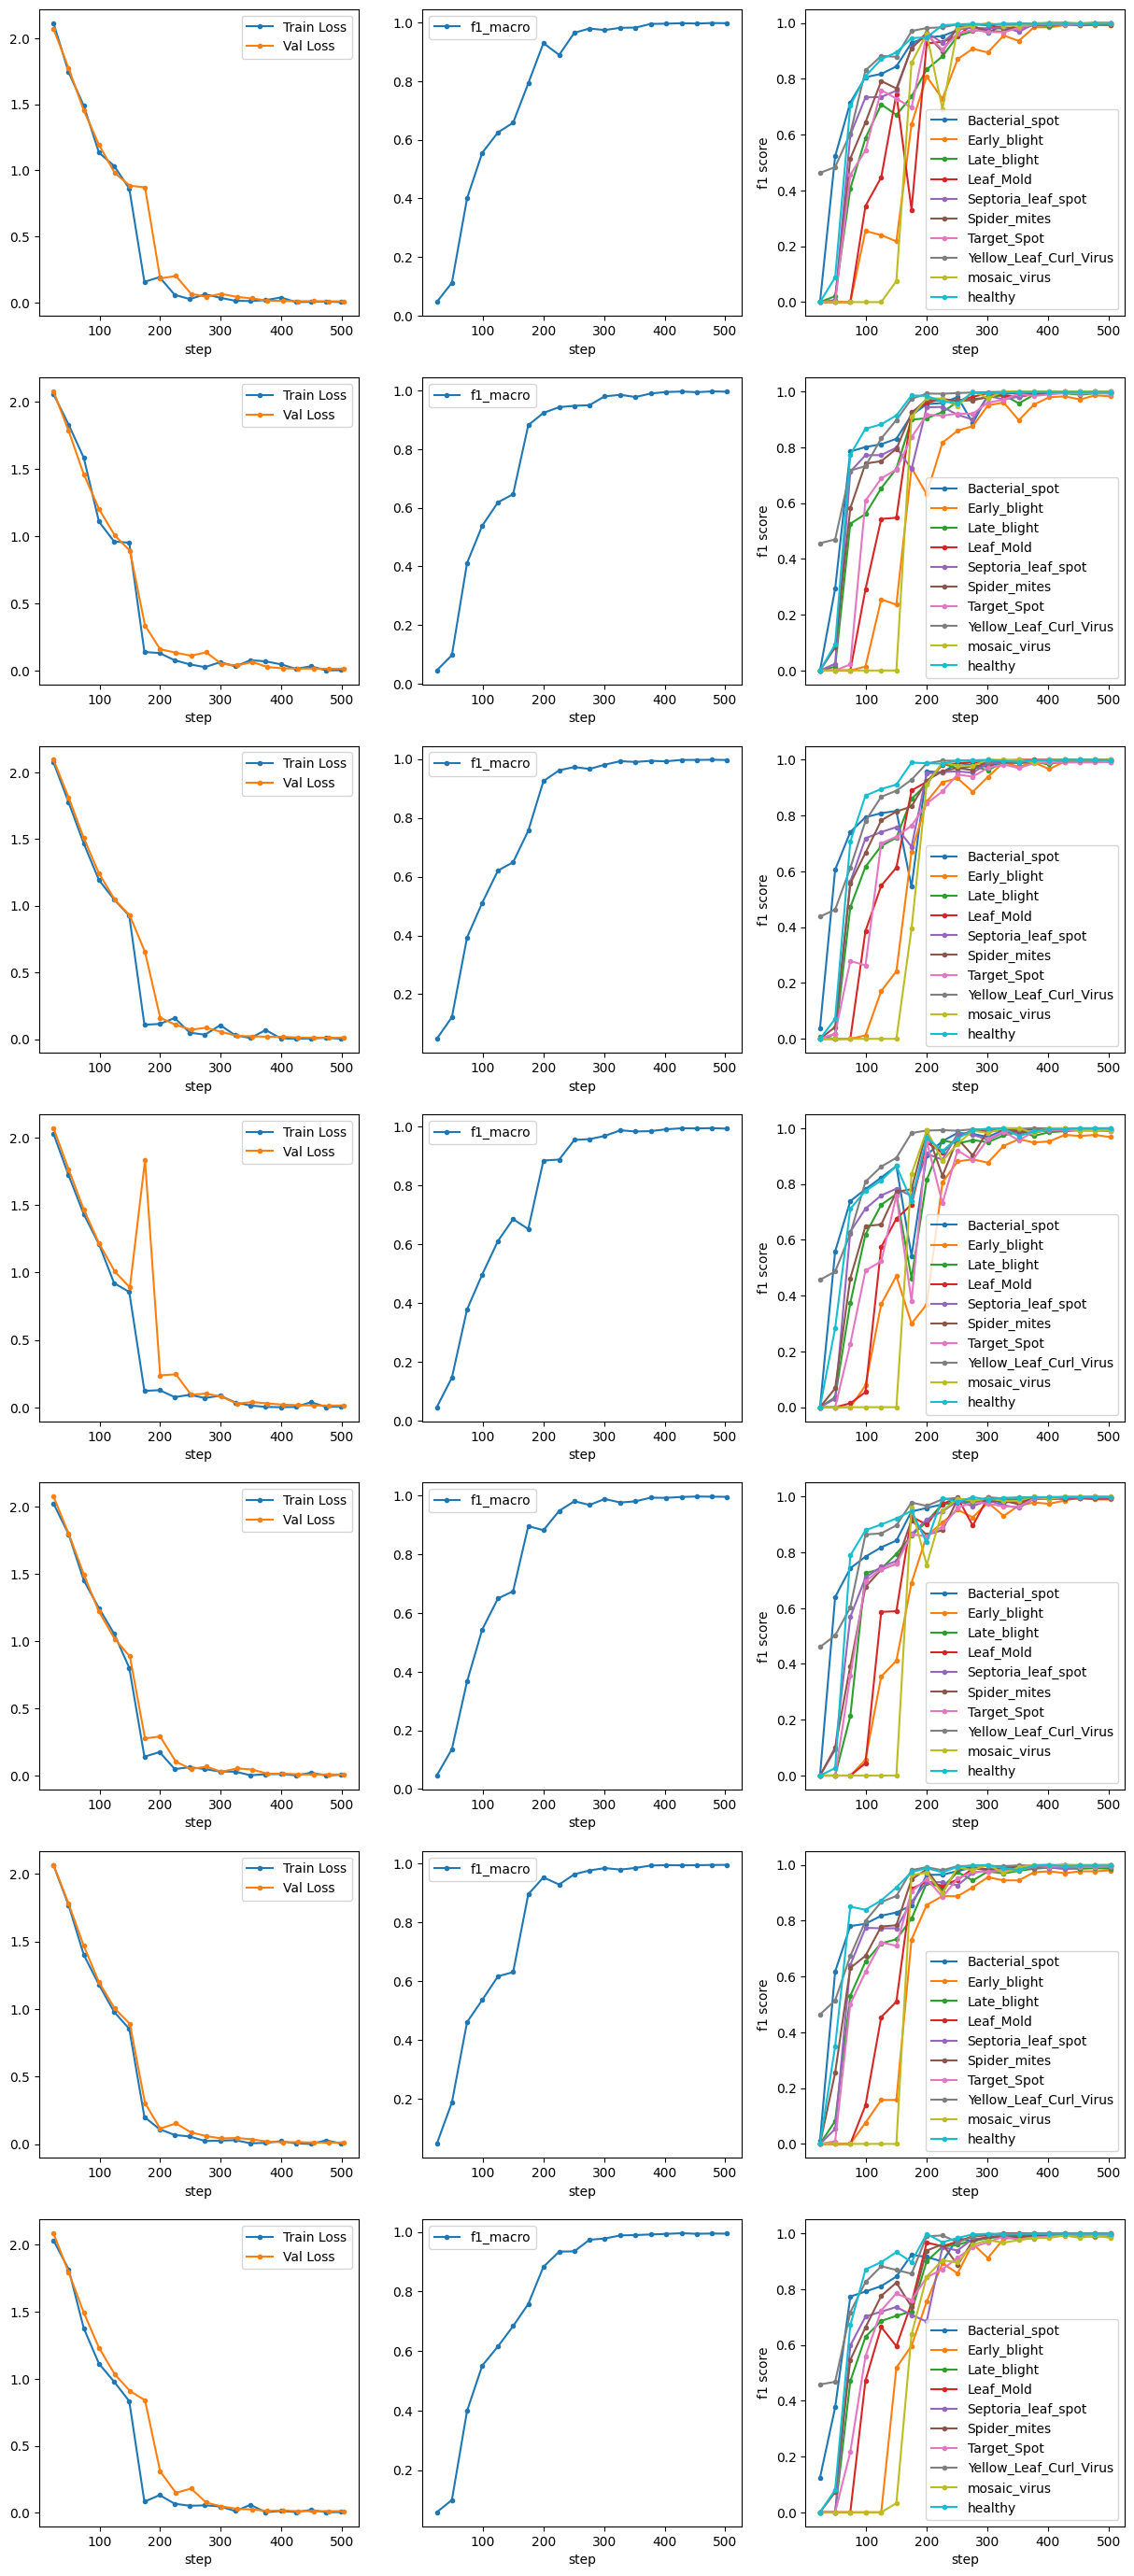

In [12]:
import glob

# Parse all generated CSV logs to plot training vs. validation metrics for each fold side-by-side
plt.figure(figsize=(15, CFG.cv * 5))
for path in glob.glob(f'{CFG.save_dir}/resnet50_baseline/*/met*'):
    fold = int(path.split('/')[-2].split('_')[1])
    metrics = pd.read_csv(path)
    
    plt.subplot(CFG.cv, 3, fold*3 +1)
    train_loss_curve = metrics.loc[:, ['step', 'train_loss_step']].dropna()
    val_loss_curve = metrics.loc[:, ['step', 'val_loss']].dropna()
    plt.plot(train_loss_curve.step, train_loss_curve.train_loss_step, ".-", label="Train Loss")
    plt.plot(val_loss_curve.step, val_loss_curve.val_loss, ".-", label="Val Loss")
    plt.xlabel('step')
    plt.legend()

    plt.subplot(CFG.cv, 3, fold*3 + 2)
    subset = metrics.loc[:, ['step', 'f1_macro']].dropna()
    plt.plot(subset['step'], subset['f1_macro'], ".-", label="f1_macro")
    plt.xlabel('step')
    plt.legend()
    
    plt.subplot(CFG.cv, 3, fold*3 + 3)
    all_f1s = [col for col in metrics.columns if col.startswith('f1_')]
    subset = metrics.loc[:, all_f1s + ['step']].dropna()
    # if chnaged logging scheme to newest then don't forget to drop the last rwo as it conatinas test statistics
    for f1 in all_f1s:
        if f1 != 'f1_macro':
            plt.plot(subset['step'], subset[f1], ".-", label=f1.replace('f1_', '').replace('Tomato_', '').split(' ')[0])
    plt.xlabel('step')
    plt.ylabel('f1 score')
    plt.legend()
plt.show()